In [2]:
print("hello world")

hello world


In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Read Parquet").getOrCreate()

df = spark.read.parquet("data/yellow_tripdata_2026-05.parquet")
df.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/06 13:56:01 WARN Utils: Your hostname, aydin-khan-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlp11s0)
26/08/06 13:56:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/06 13:56:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where app

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


(array([2.000000e+01, 4.090443e+06, 3.650000e+02, 3.000000e+00,
        1.000000e+00, 1.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 3.000000e+00]),
 array([-950.   , -302.401,  345.198,  992.797, 1640.396, 2287.995,
        2935.594, 3583.193, 4230.792, 4878.391, 5525.99 ]),
 <BarContainer object of 10 artists>)

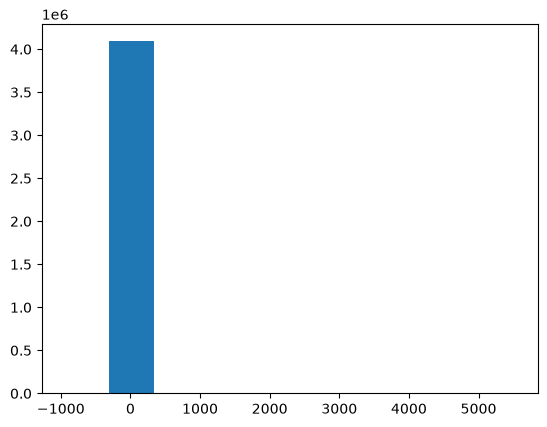

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.hist(df.select("fare_amount").toPandas()["fare_amount"])

In [5]:
df.select("fare_amount").describe().show()

+-------+------------------+
|summary|       fare_amount|
+-------+------------------+
|  count|           4090836|
|   mean|21.513196713343525|
| stddev|19.013031916167243|
|    min|            -950.0|
|    max|           5525.99|
+-------+------------------+



In [21]:
df.filter(df.tpep_pickup_datetime == df.tpep_dropoff_datetime).groupBy("VendorID").count().show()

+--------+-----+
|VendorID|count|
+--------+-----+
|       1|  285|
|       7|51750|
|       2|   28|
+--------+-----+



In [ ]:
df.filter(df.RatecodeID == 99).count().show()

4090836

In [18]:
df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2026-05-01 00:04:59|  2026-05-01 00:32:48|              1|         7.51|         1|                 N|         138|    